# Homework Starter — Stage 08 EDA

Fill in the marked TODOs. This notebook generates synthetic data so you can focus on the EDA flow. Replace with your dataset when ready.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install --upgrade pandas   # if an older pandas is already installed

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import skew, kurtosis
sns.set(context='talk', style='whitegrid')
np.random.seed(8)
pd.set_option('display.max_columns', 100)

# === Synthetic data generator (adapt or replace with your own data) ===
n = 160
df = pd.DataFrame({
    'date': pd.date_range('2021-02-01', periods=n, freq='D'),
    'region': np.random.choice(['North','South','East','West'], size=n),
    'age': np.random.normal(40, 8, size=n).clip(22, 70).round(1),
    'income': np.random.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
    'transactions': np.random.poisson(lam=3, size=n),
})
base = df['income'] * 0.0015 + df['transactions']*18 + np.random.normal(0, 40, size=n)
df['spend'] = np.maximum(0, base).round(2)

# inject a bit of missingness and outliers
df.loc[np.random.choice(df.index, 5, replace=False), 'income'] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), 'spend'] = np.nan
df.loc[np.random.choice(df.index, 2, replace=False), 'transactions'] = df['transactions'].max()+12
df.head()

,date,region,age,income,transactions,spend
0,2021-02-01,West,37.6,28086.81,4,73.35
1,2021-02-02,North,43.0,33034.75,1,52.37
2,2021-02-03,South,38.2,50045.39,2,131.85
3,2021-02-04,South,24.9,39467.28,4,147.58
4,2021-02-05,South,59.8,31201.65,1,86.76


## 1) First look

In [3]:
df.info(), df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          160 non-null    datetime64[us]
 1   region        160 non-null    str           
 2   age           160 non-null    float64       
 3   income        155 non-null    float64       
 4   transactions  160 non-null    int64         
 5   spend         157 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(1)
memory usage: 8.3 KB


(None,
 date            0
 region          0
 age             0
 income          5
 transactions    0
 spend           3
 dtype: int64)

## 2) Numeric profile

In [4]:
desc = df[['age','income','transactions','spend']].describe().T
desc['skew'] = [skew(df[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df[c].dropna()) for c in desc.index]
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,160.0,40.018750,8.458676,22.00,34.70,40.15,44.925,61.10,0.069538,-0.080125
income,155.0,41983.866323,13262.457038,17928.80,32471.53,39332.52,49697.690,87052.40,0.993336,0.918722
transactions,160.0,3.237500,2.585610,0.00,2.00,3.00,4.000,20.00,3.466078,19.984802
spend,157.0,117.291592,51.768645,0.54,77.25,119.32,153.340,280.05,0.130860,-0.084917


## 2b) Categorical profile

`.describe()` above covers the **numeric** columns only. Every non-numeric column needs
its own look: how many distinct values it has, how lopsided the split is, and whether one
category dominates so heavily that it will be useless as a feature.

`region` is the categorical column in this synthetic set. Your own dataset may have
several — profile all of them.

Value counts for column 'date':
date
2021-02-01    1
2021-02-02    1
2021-02-03    1
2021-02-04    1
2021-02-05    1
             ..
2021-07-06    1
2021-07-07    1
2021-07-08    1
2021-07-09    1
2021-07-10    1
Name: count, Length: 160, dtype: int64


Value counts for column 'region':
region
West     47
East     42
South    36
North    35
Name: count, dtype: int64




<Axes: xlabel='region', ylabel='count'>

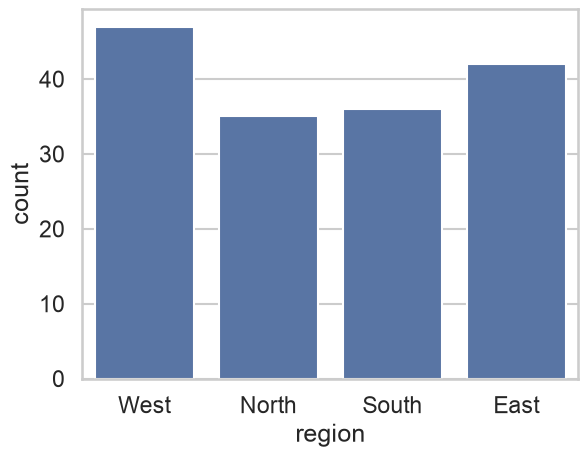

In [5]:
# TODO: value counts for every non-numeric column.

#   Hint: df.select_dtypes(exclude='number').columns gives you the list.
non_numeric_columns = df.select_dtypes(exclude='number').columns
for i in non_numeric_columns:
    print(f"Value counts for column '{i}':")
    print(df[i].value_counts())
    print("\n")

#   Print counts AND proportions — a raw count hides how lopsided a split is.

# TODO: plot one of them with sns.countplot (the lecture uses this in section 3).
sns.countplot(data=df, x=non_numeric_columns[1])

## 3) Distributions — two worked examples below; add at least one more

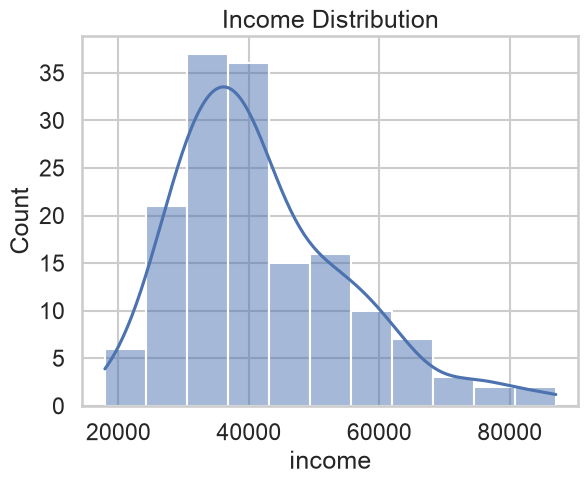

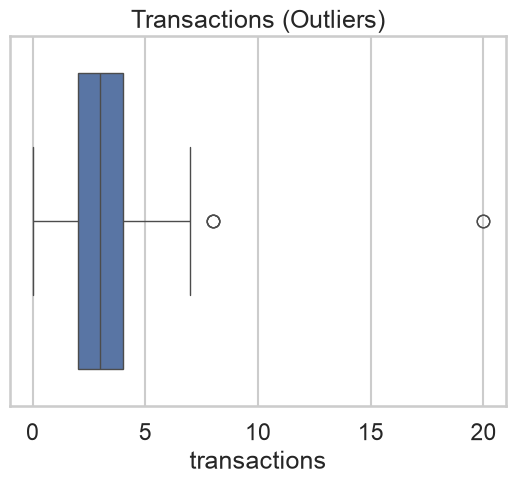

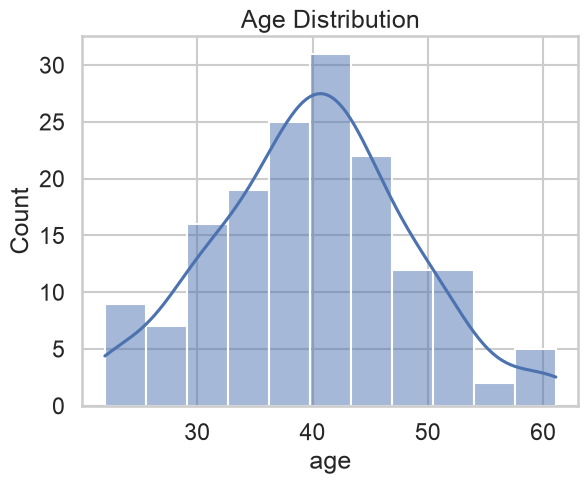

In [6]:
# Example 1 of 2 — histogram + KDE. Keep it, or swap in a column of your own.
sns.histplot(df['income'], kde=True)
plt.title('Income Distribution')
plt.show()

# Example 2 of 2 — boxplot, to expose outliers.
#
# TODO: add ONE more distribution below, on a column of your choosing (3 are required).
sns.boxplot(x=df['transactions'])
plt.title('Transactions (Outliers)')
plt.show()

sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

## 4) Relationships — both are worked below; swap in your own columns

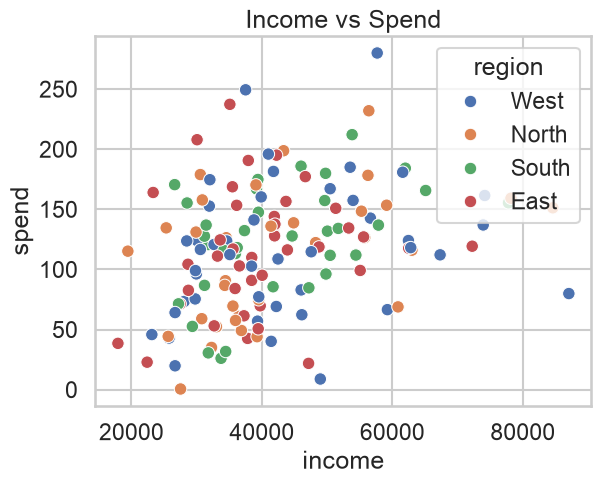

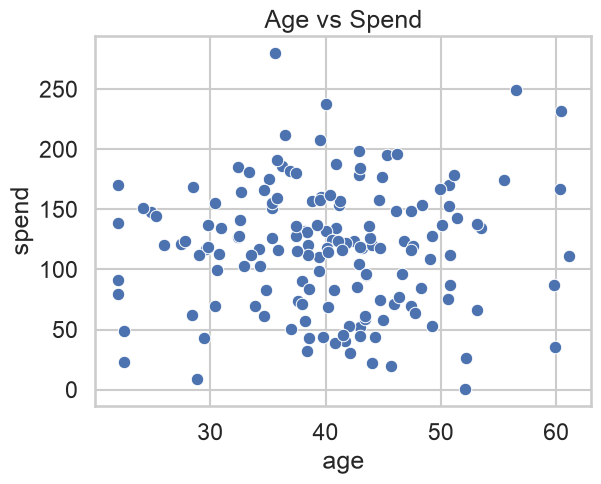

In [7]:
sns.scatterplot(data=df, x='income', y='spend', hue='region')
plt.title('Income vs Spend')
plt.show()

sns.scatterplot(data=df, x='age', y='spend')
plt.title('Age vs Spend')
plt.show()

## 4b) Over time

Nothing above uses the `date` column — and a dataset with a date almost always has
something to say along it: a trend, a seasonal cycle, or a level shift where behaviour
changed.

This is not optional detail. Stage 09 builds lag and rolling features on exactly this
axis, and stage 10b splits the data on it. What you find here decides what those stages
can do — and if the rows are out of order, or there are gaps in the dates, both of
those stages produce nonsense without telling you.

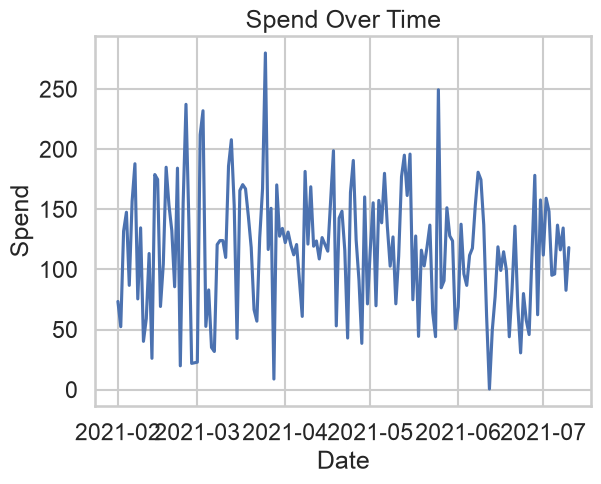

Date gaps (in days):
date
1.0    159
Name: count, dtype: int64


In [8]:
# TODO: plot at least one variable over time.
df['date'] = pd.to_datetime(df['date'])  # ensure proper datetime dtype before sorting
sorted_df = df.sort_values('date').set_index('date')

sns.lineplot(data=sorted_df, x=sorted_df.index, y='spend')
plt.title('Spend Over Time')
plt.xlabel('Date')
plt.ylabel('Spend')
plt.show()

# TODO: check for GAPS in the dates too.
date_gaps = sorted_df.index.to_series().diff().dt.days
print("Date gaps (in days):")
print(date_gaps.value_counts(dropna=True))


# TODO: then say what you see in a markdown cell: trend, seasonality, a level shift, or
#   genuinely nothing. 'Nothing' is a real finding if you can show it.


## Observations: Spend Over Time

- **Trend:** None visible. Spend oscillates around a roughly stable mean (~100–150) from Feb through July 2021, with no sustained upward or downward drift.
- **Seasonality:** No clear repeating pattern at a fixed interval; peaks and dips appear irregular rather than periodic.
- **Level shift:** None apparent. The range and volatility look consistent across the full time window.
- **Overall:** This looks like a case of "nothing". The series is dominated by high-frequency noise rather than any discernible trend, seasonality, or structural break. Spend appears to fluctuate randomly around a stable average.

## 5) (Optional) Correlation matrix

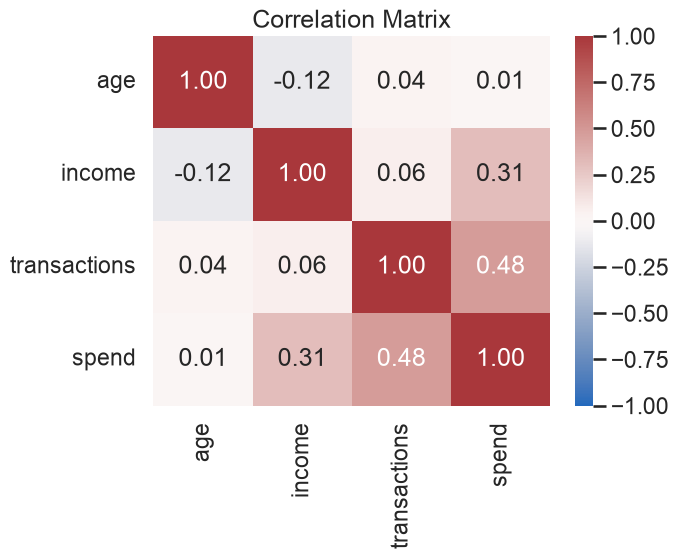

,age,income,transactions,spend
age,1.000000,-0.123160,0.037754,0.008174
income,-0.123160,1.000000,0.063573,0.307307
transactions,0.037754,0.063573,1.000000,0.480685
spend,0.008174,0.307307,0.480685,1.000000


In [9]:
corr = df[['age','income','transactions','spend']].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()
corr

## 5b) Your reusable helper — `src/eda.py`

The lecture built `eda_summary(df)` in its section 8. Copy it into `src/eda.py`, import
it here, and call it.

Stage 06 gave your project `src/cleaning.py` and stage 09 will want `src/features.py`.
This is stage 08's contribution to the same set, and the point is that your project keeps
ONE profiling function instead of ten pasted copies of it.

In [10]:
# TODO: create src/eda.py, paste the lecture's eda_summary() into it, then:
from src.eda import eda_summary, flag_columns
eda_summary(df)

# TODO (stretch): have it flag columns that need attention before stage 09 — high
#   missingness, near-zero variance, or one category dominating.

flagged_columns = flag_columns(df)
if flagged_columns:
    print("Flagged Columns:")
    for col, issue, value in flagged_columns:
        print(f"Column: {col}, Issue: {issue}, Value: {value:.2f}")
else:
    print("No columns flagged for attention.")

No columns flagged for attention.


## 6) Insights & Assumptions (write your commentary)
- TODO: Top 3 insights
- TODO: Assumptions & risks
- TODO: Next steps before modeling (cleaning & features)